# EDA 03: RNA Expression

## Purpose

A gene is a stretch of DNA that contains instructions for making a molecule. Before most proteins are made, the cell copies those instructions into RNA. RNA expression tells us how much of that RNA was detected in a cell line. It is useful because a cell cannot normally depend on the protein product of a gene if that gene's RNA is never detected, but RNA alone does not prove that a gene is important or that two genes work together.

This notebook audits the default-RNA expression matrix, checks how it was connected to models, and explores expression levels without turning missing measurements or low RNA into a biological conclusion.

## Questions

1. Does every expression row represent one default RNA profile for one valid `model_id`?
2. How much RNA is detected across models and genes, and are there technical gaps?
3. Which genes are broadly expressed, rarely detected, or highly variable across cell lines?
4. Does expression coverage differ by cancer lineage?
5. For example gene pairs, does apparent co-expression remain after allowing for lineage?

**Important:** the values are `log2(TPM + 1)`. TPM is a way of scaling RNA-sequencing counts so samples can be compared. A value of 0 means RNA was not detected by this assay; it does not prove the gene is deleted, permanently switched off, or biologically irrelevant.

## Considerations carried forward

- Use `model_id` as the only automatic model-level join key.
- Use the default RNA profile so repeated sequencing does not make one cell line count more than once.
- Report the number of models used for every expression or correlation result.
- Compare lineages before calling two genes co-expressed: two genes may both be high in one cancer type without directly affecting one another.
- Treat an unavailable RNA measurement as missing evidence, not as zero expression.
- RNA expression is supporting context for a gene pair. It is not proof of fusion, dependency, synthetic lethality, or physical binding.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'expression_default': DATA / 'derived' / 'expression_default_rna_model.csv',
    'expression_profile': DATA / 'raw' / 'OmicsExpressionAllGenesTPMLogp1Profile.csv',
    'omics_profiles': DATA / 'raw' / 'OmicsProfiles.csv',
    'default_profiles': DATA / 'raw' / 'OmicsDefaultModelProfiles.csv',
    'gene_master': DATA / 'architecture' / 'gene_master.csv',
}
for name, path in PATHS.items():
    print(f'{name}: {path}')

master: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\architecture\model_master.csv
expression_default: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\derived\expression_default_rna_model.csv
expression_profile: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\raw\OmicsExpressionAllGenesTPMLogp1Profile.csv
omics_profiles: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\raw\OmicsProfiles.csv
default_profiles: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\raw\OmicsDefaultModelProfiles.csv
gene_master: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\architecture\gene_master.csv


In [2]:
master = pd.read_csv(PATHS['master'], low_memory=False)
omics_profiles = pd.read_csv(PATHS['omics_profiles'], low_memory=False)
default_profiles = pd.read_csv(PATHS['default_profiles'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)

# Reading only the header avoids loading the 1 GB expression matrix into memory at this point.
expression_columns = pd.read_csv(PATHS['expression_default'], nrows=0).columns.tolist()
assert expression_columns[0] == 'model_id'
gene_columns = expression_columns[1:]

print(f'Master models: {len(master):,}')
print(f'Default-expression matrix: one model key + {len(gene_columns):,} gene columns')
print(f'RNA profiles in OmicsProfiles: {(omics_profiles["Datatype"].eq("rna")).sum():,}')
display(master[['model_id', 'oncotree_lineage', 'has_expression', 'default_rna_profile_id']].head())

Master models: 2,105
Default-expression matrix: one model key + 53,969 gene columns
RNA profiles in OmicsProfiles: 1,690


,model_id,oncotree_lineage,has_expression,default_rna_profile_id
0,ACH-000001,Ovary/Fallopian Tube,1,PR-vFBZ2h
1,ACH-000002,Myeloid,1,PR-yEldOx
2,ACH-000003,Bowel,1,PR-jIbcm8
3,ACH-000004,Myeloid,1,PR-pEZmVx
4,ACH-000005,Myeloid,1,PR-y0OM3W


## Column dictionary

| Table / column | Plain-language meaning | Use in this project |
| --- | --- | --- |
| `expression_default_rna_model.model_id` | DepMap identifier for the cell line whose chosen RNA profile is shown. | The only automatic join key to the model table. |
| `expression_default_rna_model.<GENE> (ENSG...)` | RNA amount for one gene in `log2(TPM + 1)` units. `ENSG...` is a stable Ensembl gene identifier. | Tells us whether gene A or B has detectable RNA and supports co-expression checks. |
| `OmicsExpressionAllGenesTPMLogp1Profile.Unnamed: 0` | Identifier for one original RNA-sequencing profile. | Used only to audit how profiles were reduced to default model rows. |
| `OmicsProfiles.ProfileID` | Identifier for one omics measurement. | Connects an RNA profile to a model and its condition. |
| `OmicsProfiles.ModelID` | DepMap model attached to that profile. | Confirms profile-to-model mapping. |
| `OmicsProfiles.ModelCondition` | Culture condition attached to the profile. | Preserves experimental context; it is not a new cell line. |
| `OmicsProfiles.Datatype` | Assay type, such as `rna`. | Prevents using a DNA profile as RNA evidence. |
| `OmicsProfiles.Product`, `Stranded`, `Source`, `SharedToDbgap` | Sequencing product, library orientation, source, and sharing metadata. | Technical/provenance context for later investigation. |
| `OmicsDefaultModelProfiles.ModelID` | Model for which a default profile was selected. | Defines one chosen RNA observation per model. |
| `OmicsDefaultModelProfiles.ProfileID` | Selected profile identifier. | Must occur in the original RNA matrix. |
| `OmicsDefaultModelProfiles.ProfileType` | Type of selected profile, such as `rna` or `dna`. | Used to select only default RNA profiles. |
| `gene_master.gene_id`, `symbol`, `ensembl_gene_id` | Project gene key, familiar gene name, and stable Ensembl identifier. | Resolves user-entered gene names to the expression column safely. |

## 1. RNA-profile and model-join audit

The original matrix is one row per sequencing profile. The derived matrix is one row per model after selecting the release-default RNA profile. This section checks that reduction rather than assuming it worked.

In [3]:
rna_profiles = omics_profiles.loc[omics_profiles['Datatype'].eq('rna')].copy()
default_rna = default_profiles.loc[default_profiles['ProfileType'].eq('rna')].copy()

# This reads only the original profile-ID column, not the full set of gene values.
raw_profile_ids = set(pd.read_csv(PATHS['expression_profile'], usecols=['Unnamed: 0'])['Unnamed: 0'])
default_model_ids = set(pd.read_csv(PATHS['expression_default'], usecols=['model_id'])['model_id'])
master_ids = set(master['model_id'])

profile_audit = pd.DataFrame([{
    'original_RNA_profiles': len(raw_profile_ids),
    'RNA_profiles_in_bridge': len(rna_profiles),
    'default_RNA_profile_rows': len(default_rna),
    'default_expression_models': len(default_model_ids),
    'default_profiles_missing_from_raw_matrix': len(set(default_rna['ProfileID']) - raw_profile_ids),
    'expression_models_missing_from_master': len(default_model_ids - master_ids),
    'default_expression_models_without_has_expression_flag': int((master.set_index('model_id').loc[list(default_model_ids), 'has_expression'].eq(0)).sum()),
}])
display(profile_audit)

assert default_rna['ModelID'].is_unique
assert not (set(default_rna['ProfileID']) - raw_profile_ids)
assert not (default_model_ids - master_ids)
print('PASS: the default RNA profile route is complete and every derived-expression model maps to model_master.')

,original_RNA_profiles,RNA_profiles_in_bridge,default_RNA_profile_rows,default_expression_models,default_profiles_missing_from_raw_matrix,expression_models_missing_from_master,default_expression_models_without_has_expression_flag
0,1690,1690,1673,1673,0,0,0


PASS: the default RNA profile route is complete and every derived-expression model maps to model_master.


### What this means for the project

One cell line can be sequenced more than once, perhaps under a different condition or by a different source. We use the chosen default RNA profile so one cell line does not get extra influence just because it was measured repeatedly. For example, if a model has two RNA profiles, both are useful for investigation, but the default one is the single value used in a model-level gene-pair calculation.

## 2. Full-matrix measurement audit

The expression matrix is very wide: around 54,000 gene columns. We scan it in small pieces rather than loading the whole file at once. This gives a broad picture of how much RNA was detected in each model and how variable each gene is across models.

,count,mean,std,min,25%,50%,75%,max
mean_log2_tpm_plus_1,1673.0,1.076204,0.105025,0.415159,1.017023,1.08322,1.146251,1.449379
detected_gene_pct,1673.0,49.348267,5.291682,32.970000,45.210000,49.93000,53.280000,65.990000


,count,mean,std,min,25%,50%,75%,max
mean_log2_tpm_plus_1,53969.0,1.076204,1.837833,0.0,0.011804,0.111658,1.232396,15.140921
sd_log2_tpm_plus_1,53969.0,0.476416,0.515950,0.0,0.070621,0.278563,0.745564,4.736965
missing_pct,53969.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
zero_pct,53969.0,50.651756,40.482796,0.0,2.810000,56.370000,93.190000,100.000000


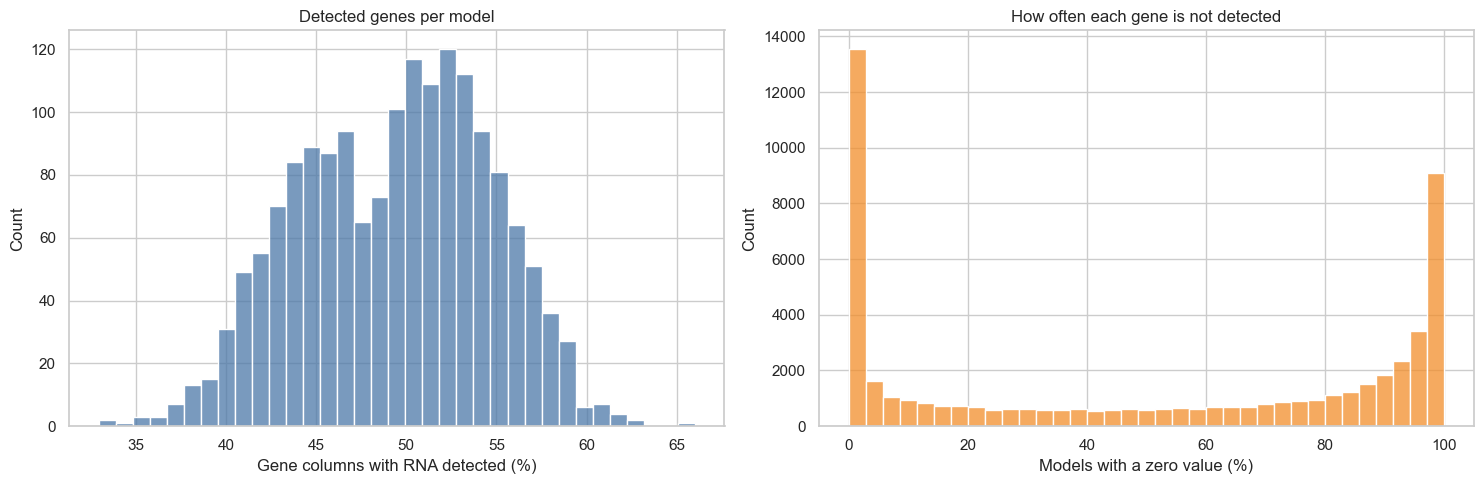

#### Genes with the highest variation across models

,expression_column,mean_log2_tpm_plus_1,sd_log2_tpm_plus_1,missing_pct,zero_pct
28974,AL162151.2 (ENSG00000234648),6.540308,4.736965,0.0,29.89
13021,KRT19 (ENSG00000171345),4.800931,4.156260,0.0,8.25
4141,SPARC (ENSG00000113140),5.424723,4.141295,0.0,1.85
12142,C19orf33 (ENSG00000167644),4.286687,3.913963,0.0,13.45
4421,FN1 (ENSG00000115414),6.307445,3.877489,0.0,0.00
5085,TGFBI (ENSG00000120708),5.542987,3.847921,0.0,3.29
6176,RPS4Y1 (ENSG00000129824),2.980903,3.823230,0.0,19.84
9745,UCHL1 (ENSG00000154277),4.877137,3.799518,0.0,6.40
12806,KRT8 (ENSG00000170421),6.683337,3.796940,0.0,1.32
452,VIM (ENSG00000026025),7.531625,3.792144,0.0,0.36


In [4]:
RUN_FULL_MATRIX_AUDIT = True  # Set to False for a quick read of this notebook.

def summarise_expression_matrix(path: Path, columns: list[str], chunk_size: int = 64):
    n_genes = len(columns) - 1
    value_sum = np.zeros(n_genes, dtype=np.float64)
    value_sum_sq = np.zeros(n_genes, dtype=np.float64)
    value_count = np.zeros(n_genes, dtype=np.int64)
    zero_count = np.zeros(n_genes, dtype=np.int64)
    model_rows = []

    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        values = chunk.iloc[:, 1:].to_numpy(dtype=np.float64, copy=False)
        valid = np.isfinite(values)
        value_sum += np.nansum(values, axis=0)
        value_sum_sq += np.nansum(values * values, axis=0)
        value_count += valid.sum(axis=0)
        zero_count += (values == 0).sum(axis=0)
        model_rows.append(pd.DataFrame({
            'model_id': chunk.iloc[:, 0].astype(str).values,
            'mean_log2_tpm_plus_1': np.nanmean(values, axis=1),
            'detected_gene_pct': (100 * (values > 0).sum(axis=1) / valid.sum(axis=1)).round(2),
        }))

    gene_mean = value_sum / value_count
    gene_variance = np.maximum(value_sum_sq / value_count - gene_mean ** 2, 0)
    gene_summary = pd.DataFrame({
        'expression_column': columns[1:],
        'mean_log2_tpm_plus_1': gene_mean,
        'sd_log2_tpm_plus_1': np.sqrt(gene_variance),
        'missing_pct': (100 * (1 - value_count / value_count.max())).round(3),
        'zero_pct': (100 * zero_count / value_count).round(2),
    })
    return pd.concat(model_rows, ignore_index=True), gene_summary

if RUN_FULL_MATRIX_AUDIT:
    model_expression_summary, gene_expression_summary = summarise_expression_matrix(PATHS['expression_default'], expression_columns)
    display(model_expression_summary.describe().T)
    display(gene_expression_summary[['mean_log2_tpm_plus_1', 'sd_log2_tpm_plus_1', 'missing_pct', 'zero_pct']].describe().T)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(model_expression_summary['detected_gene_pct'], bins=35, ax=axes[0], color='#4C78A8')
    axes[0].set_title('Detected genes per model')
    axes[0].set_xlabel('Gene columns with RNA detected (%)')
    sns.histplot(gene_expression_summary['zero_pct'], bins=35, ax=axes[1], color='#F28E2B')
    axes[1].set_title('How often each gene is not detected')
    axes[1].set_xlabel('Models with a zero value (%)')
    plt.tight_layout(); plt.show()

    display(Markdown('#### Genes with the highest variation across models'))
    display(gene_expression_summary.nlargest(20, 'sd_log2_tpm_plus_1'))
else:
    print('Full-matrix audit skipped. Set RUN_FULL_MATRIX_AUDIT = True to run the chunked scan.')

### What this means for the project

A gene that is detected in almost every model is useful for checking that the assay worked, but it is less likely to explain why only some cell lines depend on another gene. A gene whose RNA level changes a lot between models may be more informative, but variation can come from cancer lineage, technical conditions, or genuine biology. We therefore treat this scan as a shortlist for careful follow-up, not as a list of important genes.

## 3. Familiar cancer-gene examples

To make the values easier to understand, we inspect a small panel of genes often discussed in cancer research. This panel includes genes involved in DNA repair (`BRCA1`, `BRCA2`), cell-cycle control (`TP53`, `RB1`, `CDKN2A`), growth signalling (`EGFR`, `KRAS`, `BRAF`, `PIK3CA`, `ERBB2`), and project-relevant examples (`ARID1A`, `EZH2`, `EML4`, `ALK`). These examples are for exploration; they are not labels for the final model.

,gene,expression_column_found
0,TP53,TP53 (ENSG00000141510)
1,BRCA1,BRCA1 (ENSG00000012048)
2,BRCA2,BRCA2 (ENSG00000139618)
3,ARID1A,ARID1A (ENSG00000117713)
4,EZH2,EZH2 (ENSG00000106462)
5,EML4,EML4 (ENSG00000143924)
6,ALK,ALK (ENSG00000171094)
7,KRAS,KRAS (ENSG00000133703)
8,EGFR,EGFR (ENSG00000146648)
9,MYC,MYC (ENSG00000136997)


,mean,median,sd,zero_pct,detected_at_or_above_1_pct
CDKN2A,3.877,4.357,2.876,8.07,70.35
EGFR,3.384,3.952,2.366,5.26,72.98
ERBB2,4.342,4.549,1.729,0.00,98.86
MYC,6.021,6.204,1.709,0.00,98.09
MDM2,5.003,4.783,1.343,0.00,100.00
TP53,5.013,5.271,1.318,0.24,98.98
EZH2,4.986,5.120,1.136,0.00,99.94
RB1,3.977,4.103,1.067,0.36,98.27
BRCA1,4.214,4.343,1.001,0.00,99.64
PTEN,4.542,4.581,0.990,0.06,98.57


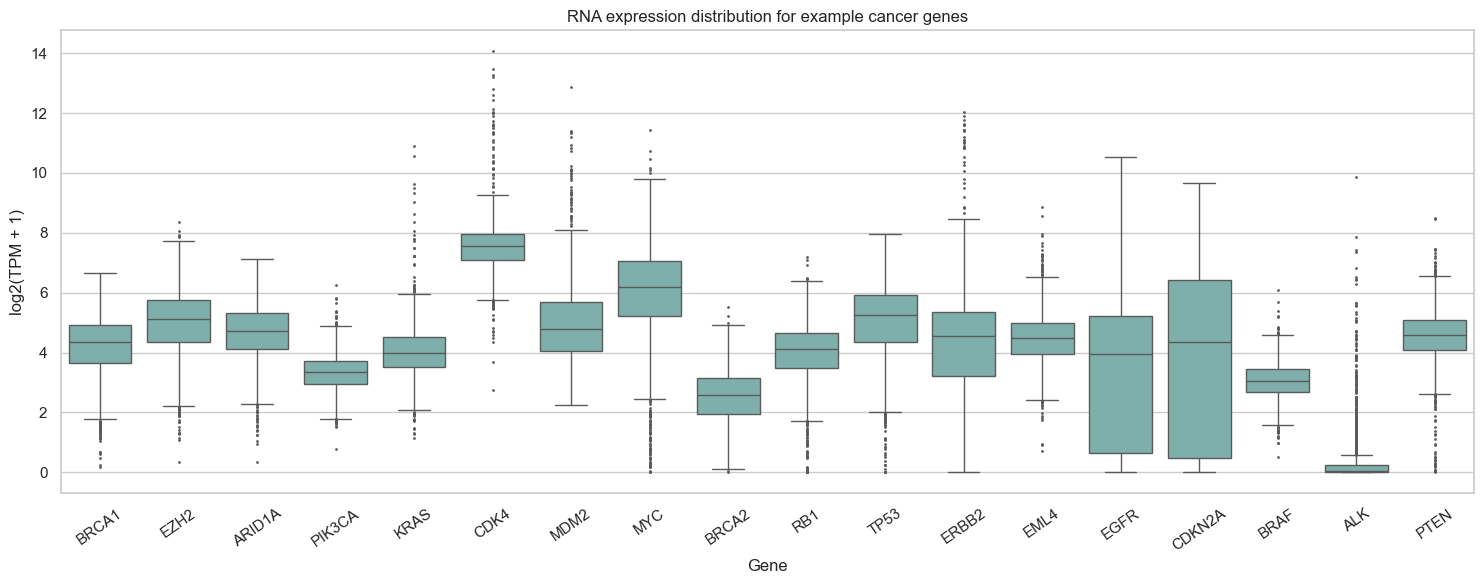

In [5]:
PANEL_GENES = ['TP53', 'BRCA1', 'BRCA2', 'ARID1A', 'EZH2', 'EML4', 'ALK', 'KRAS', 'EGFR', 'MYC', 'RB1', 'CDKN2A', 'BRAF', 'PTEN', 'PIK3CA', 'ERBB2', 'MDM2', 'CDK4']
gene_lookup = gene_master.dropna(subset=['symbol', 'ensembl_gene_id']).drop_duplicates('symbol').set_index('symbol')['ensembl_gene_id'].to_dict()

def expression_column_for_gene(symbol: str) -> str | None:
    ensembl = gene_lookup.get(symbol)
    expected = f'{symbol} ({ensembl})' if ensembl else None
    if expected in expression_columns:
        return expected
    matches = [column for column in gene_columns if column.startswith(f'{symbol} (')]
    return matches[0] if len(matches) == 1 else None

gene_to_column = {gene: expression_column_for_gene(gene) for gene in PANEL_GENES}
available_gene_to_column = {gene: column for gene, column in gene_to_column.items() if column is not None}
display(pd.DataFrame({'gene': gene_to_column.keys(), 'expression_column_found': gene_to_column.values()}))

expression_panel = pd.read_csv(PATHS['expression_default'], usecols=['model_id', *available_gene_to_column.values()])
expression_panel = expression_panel.rename(columns={column: gene for gene, column in available_gene_to_column.items()})

panel_summary = pd.DataFrame({
    'mean': expression_panel[list(available_gene_to_column)].mean(),
    'median': expression_panel[list(available_gene_to_column)].median(),
    'sd': expression_panel[list(available_gene_to_column)].std(),
    'zero_pct': (100 * expression_panel[list(available_gene_to_column)].eq(0).mean()).round(2),
    'detected_at_or_above_1_pct': (100 * expression_panel[list(available_gene_to_column)].ge(1).mean()).round(2),
}).sort_values('sd', ascending=False)
display(panel_summary.round(3))

panel_long = expression_panel.melt(id_vars='model_id', var_name='gene', value_name='log2_tpm_plus_1')
plt.figure(figsize=(15, 6))
sns.boxplot(data=panel_long, x='gene', y='log2_tpm_plus_1', color='#76B7B2', fliersize=1)
plt.title('RNA expression distribution for example cancer genes')
plt.xlabel('Gene'); plt.ylabel('log2(TPM + 1)')
plt.xticks(rotation=35); plt.tight_layout(); plt.show()

### What this means for the project

The box plots show how much each example gene's RNA differs across cell lines. For instance, if `ALK` has RNA detected in only a small group of models, that can be useful context for an `EML4--ALK` fusion query. It still does not show that the fusion exists: fusion evidence must come from the fusion table. Likewise, high `BRCA1` RNA does not prove that BRCA1 is functioning normally; mutation and copy-number data are needed for that question.

## 4. Expression coverage and levels by cancer lineage

A lineage is a broad cancer group, such as lung, breast, or blood-related cancers. RNA measurements may cover some lineages better than others. Also, a gene can be high in one lineage simply because that tissue normally uses it more, rather than because it is related to a dependency.

,models,expression_models,expression_coverage_pct
oncotree_lineage,,,
Lung,260,214,82.3
Lymphoid,260,186,71.5
Skin,149,120,80.5
CNS/Brain,125,100,80.0
Esophagus/Stomach,103,77,74.8
Bowel,99,86,86.9
Breast,96,70,72.9
Head and Neck,95,74,77.9
Bone,90,55,61.1


#### Median RNA level by lineage for the example genes (lineages with at least 20 master models)

,TP53,BRCA1,BRCA2,ARID1A,EZH2,EML4,ALK,KRAS,EGFR,MYC,RB1,CDKN2A,BRAF,PTEN,PIK3CA,ERBB2,MDM2,CDK4
oncotree_lineage,,,,,,,,,,,,,,,,,,
Biliary Tract,5.32,3.92,1.87,3.89,4.14,4.52,0.01,4.11,5.18,6.28,4.00,4.51,2.61,4.40,2.97,5.08,5.39,7.56
Bladder/Urinary Tract,5.30,4.71,2.77,4.70,5.22,4.69,0.01,4.02,5.48,6.32,3.61,4.07,3.05,4.44,3.40,5.32,4.58,7.61
Bone,5.57,4.34,2.64,4.96,5.27,4.93,0.28,4.15,1.81,6.24,4.14,4.34,3.03,4.33,3.51,4.18,4.59,8.00
Bowel,5.45,4.27,2.97,4.58,5.24,4.97,0.01,4.14,3.86,6.86,4.16,4.41,3.03,4.56,2.95,5.57,4.43,7.58
Breast,5.14,3.78,2.46,4.80,5.16,4.16,0.06,3.82,3.38,5.94,3.60,4.47,2.98,4.51,3.20,5.98,4.63,7.13
CNS/Brain,5.59,4.34,2.49,4.73,5.24,4.33,0.12,3.86,4.47,5.27,4.47,0.49,3.13,4.27,3.59,4.45,4.35,7.74
Cervix,5.14,4.26,2.20,3.80,4.93,4.12,0.01,3.39,5.44,5.36,3.80,7.19,2.69,4.71,3.11,5.11,6.13,7.58
Esophagus/Stomach,5.45,4.38,2.80,4.75,5.01,4.71,0.08,4.03,5.19,6.56,4.09,3.81,2.99,4.60,3.34,5.51,4.44,7.37
Eye,5.13,3.85,1.88,4.12,4.05,3.88,0.24,3.54,1.32,6.43,3.72,3.72,2.68,4.69,2.84,4.26,5.60,7.80


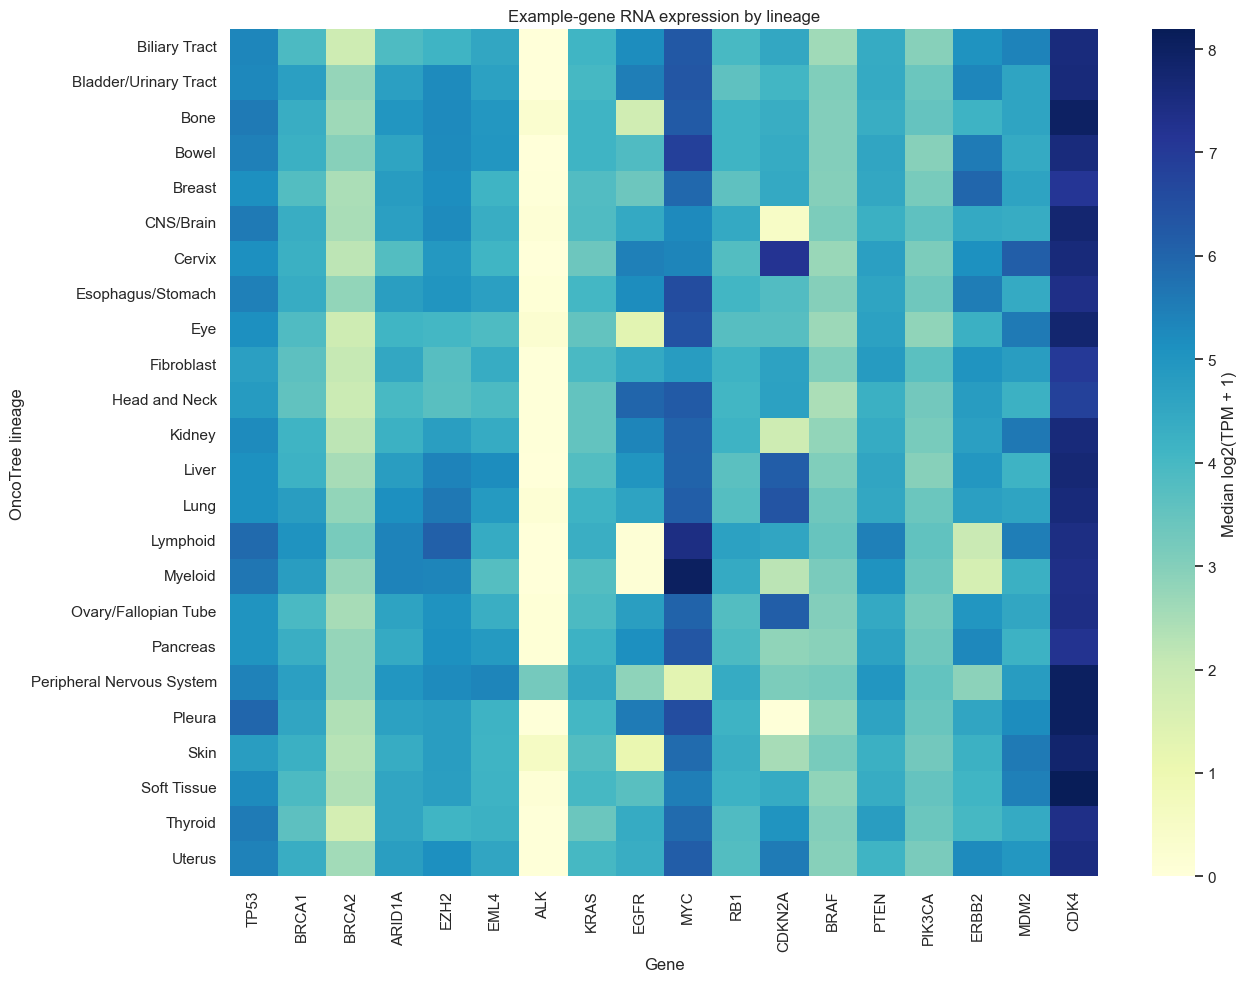

In [6]:
lineage_master = master.groupby('oncotree_lineage', dropna=False).agg(models=('model_id', 'size'), expression_models=('has_expression', 'sum'))
lineage_master['expression_coverage_pct'] = (100 * lineage_master['expression_models'] / lineage_master['models']).round(1)
display(lineage_master.sort_values('models', ascending=False))

panel_with_lineage = expression_panel.merge(master[['model_id', 'oncotree_lineage']], on='model_id', how='left', validate='one_to_one')
large_lineages = lineage_master.query('models >= 20').index
lineage_panel_medians = panel_with_lineage.loc[panel_with_lineage['oncotree_lineage'].isin(large_lineages)].groupby('oncotree_lineage')[list(available_gene_to_column)].median()

display(Markdown('#### Median RNA level by lineage for the example genes (lineages with at least 20 master models)'))
display(lineage_panel_medians.round(2))

plt.figure(figsize=(14, 11))
sns.heatmap(lineage_panel_medians, cmap='YlGnBu', cbar_kws={'label': 'Median log2(TPM + 1)'})
plt.title('Example-gene RNA expression by lineage')
plt.xlabel('Gene'); plt.ylabel('OncoTree lineage')
plt.show()

### What this means for the project

Suppose two genes are both high in melanoma but lower elsewhere. Their overall correlation may look strong even if they do not directly regulate one another. The lineage heatmap helps us see that possibility. When we create a pair feature later, we will either calculate it inside a sufficiently large lineage or remove the lineage median before comparing the genes.

## 5. Example gene-pair expression checks

We now compare a few example pairs. Spearman correlation asks whether two values tend to rise and fall together, based on their rank rather than their exact scale. We show both an all-model correlation and a lineage-adjusted correlation. A similar adjusted value is more reassuring that the pattern is not only caused by cancer type, but neither value proves a biological interaction.

,gene_a,gene_b,models_with_both_measurements,all_model_spearman,models_in_lineages_n_at_least_15,lineage_adjusted_spearman
0,BRCA1,BRCA2,1668,0.680,1628,0.651
1,ARID1A,EZH2,1668,0.658,1628,0.581
2,EML4,ALK,1668,0.095,1628,0.080
3,EGFR,KRAS,1668,-0.096,1628,-0.041


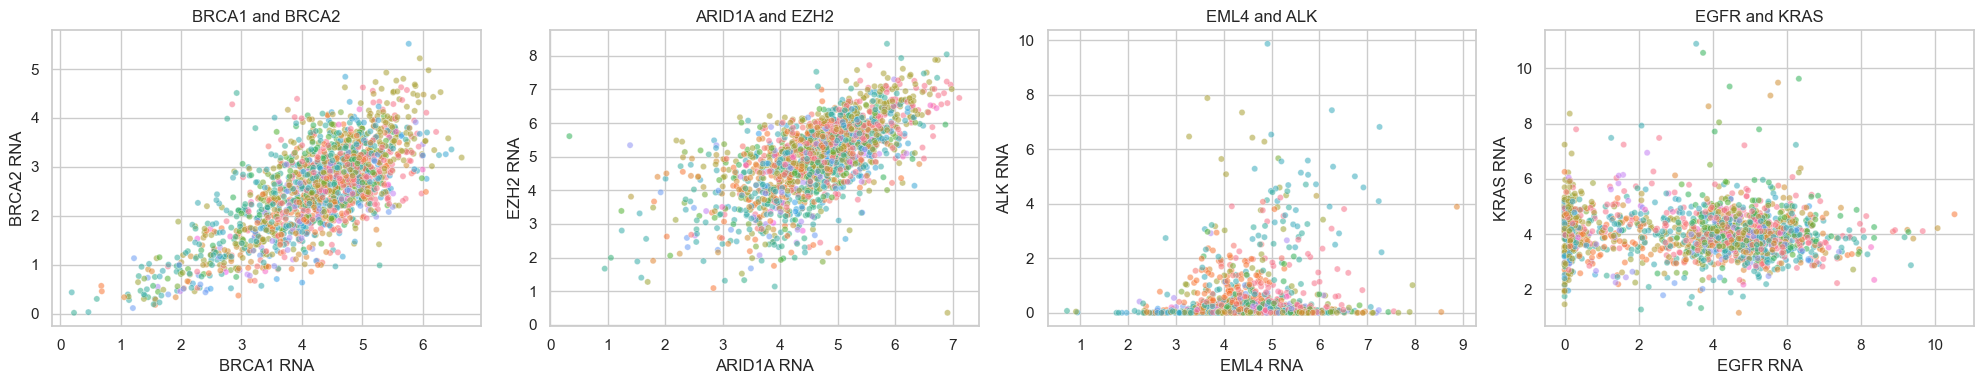

#### Threshold sensitivity: how many models have detectable RNA for both genes?

,gene_pair,threshold_log2_tpm_plus_1,models_with_both_genes_at_or_above_threshold
0,BRCA1-BRCA2,0.5,1641
1,BRCA1-BRCA2,1.0,1560
2,BRCA1-BRCA2,2.0,1219
3,ARID1A-EZH2,0.5,1671
4,ARID1A-EZH2,1.0,1670
5,ARID1A-EZH2,2.0,1641
6,EML4-ALK,0.5,280
7,EML4-ALK,1.0,186
8,EML4-ALK,2.0,97
9,EGFR-KRAS,0.5,1268


In [7]:
PAIR_EXAMPLES = [('BRCA1', 'BRCA2'), ('ARID1A', 'EZH2'), ('EML4', 'ALK'), ('EGFR', 'KRAS')]

def pair_expression_summary(frame: pd.DataFrame, gene_a: str, gene_b: str, minimum_lineage_size: int = 15) -> dict:
    selected = frame[['oncotree_lineage', gene_a, gene_b]].dropna()
    all_models_corr = selected[gene_a].corr(selected[gene_b], method='spearman')
    usable = selected.groupby('oncotree_lineage')[gene_a].transform('size').ge(minimum_lineage_size)
    lineage_selected = selected.loc[usable].copy()
    residuals = lineage_selected[[gene_a, gene_b]] - lineage_selected.groupby('oncotree_lineage')[[gene_a, gene_b]].transform('median')
    return {
        'gene_a': gene_a, 'gene_b': gene_b, 'models_with_both_measurements': len(selected),
        'all_model_spearman': all_models_corr,
        'models_in_lineages_n_at_least_15': len(lineage_selected),
        'lineage_adjusted_spearman': residuals[gene_a].corr(residuals[gene_b], method='spearman'),
    }

available_pairs = [(a, b) for a, b in PAIR_EXAMPLES if a in expression_panel and b in expression_panel]
pair_results = pd.DataFrame([pair_expression_summary(panel_with_lineage, a, b) for a, b in available_pairs])
display(pair_results.round(3))

fig, axes = plt.subplots(1, len(available_pairs), figsize=(5 * len(available_pairs), 4))
if len(available_pairs) == 1:
    axes = [axes]
for ax, (gene_a, gene_b) in zip(axes, available_pairs):
    sns.scatterplot(data=panel_with_lineage, x=gene_a, y=gene_b, hue='oncotree_lineage', alpha=0.55, s=20, legend=False, ax=ax)
    ax.set_title(f'{gene_a} and {gene_b}')
    ax.set_xlabel(f'{gene_a} RNA')
    ax.set_ylabel(f'{gene_b} RNA')
plt.tight_layout(); plt.show()

thresholds = [0.5, 1.0, 2.0]
both_detected = []
for gene_a, gene_b in available_pairs:
    for threshold in thresholds:
        both_detected.append({
            'gene_pair': f'{gene_a}-{gene_b}',
            'threshold_log2_tpm_plus_1': threshold,
            'models_with_both_genes_at_or_above_threshold': int(expression_panel[[gene_a, gene_b]].ge(threshold).all(axis=1).sum()),
        })
display(Markdown('#### Threshold sensitivity: how many models have detectable RNA for both genes?'))
display(pd.DataFrame(both_detected))

### What this means for the project

Co-expression is a supporting clue only. For example, `BRCA1` and `BRCA2` may have similar RNA patterns because both are active in rapidly dividing cells, while `ARID1A` and `EZH2` can be clinically interesting even if their RNA values are not strongly correlated. The later model will use RNA as one transparent feature alongside mutations, copy number, fusions, and CRISPR dependency. It will always state how many models had measured RNA for both queried genes.

## Decisions carried into feature engineering

- Use the default-RNA model matrix, keyed by `model_id`, for model-level RNA features.
- Resolve gene symbols through `gene_master` before selecting an expression column; never match a gene by a loose text search.
- Keep RNA availability separate from an observed value of zero. Missing RNA means the model is outside the denominator.
- For a queried pair, report gene-A RNA, gene-B RNA, number of models with both values, and threshold sensitivity rather than claiming a single universal expression cutoff.
- Calculate co-expression within a lineage or after lineage adjustment, and label small-lineage results as exploratory.
- Do not use co-expression as a label for synthetic lethality or fusion. It is visible supporting evidence in a wider white-box explanation.